In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_colwidth', 120)

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

In [5]:
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

Train shape: (120000, 3)
Test shape: (7600, 3)


In [6]:
print('Columns:', list(train_df.columns))

Columns: ['Class Index', 'Title', 'Description']


In [7]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\contr..."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over...
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed...
4,3,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three ..."


In [23]:
CLASS_NAMES = { 1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}

train_df['Class Name'] = train_df['Class Index'].map(CLASS_NAMES)
test_df['Class Name'] = test_df['Class Index'].map(CLASS_NAMES)

In [25]:
train_df[['Class Index', 'Class Name', 'Title', 'Description']].sample(5, random_state=42)

,Class Index,Class Name,Title,Description
71787,3,Business,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarte..."
67218,3,Business,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reu...
54066,2,Sports,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year...
7168,4,Sci/Tech,Flying the Sun to Safety,"When the Genesis capsule comes back to Earth with its samples of the sun, helicopter pilots will be waiting for it, ..."
29618,3,Business,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to open near unchanged on Thursday after a warning from technology bell...


In [26]:
print('Missing Values (train) :')
print(train_df.isnull().sum())

print('Missing values (test) :')
print(test_df.isnull().sum())

Missing Values (train) :
Class Index    0
Title          0
Description    0
Class Name     0
dtype: int64
Missing values (test) :
Class Index    0
Title          0
Description    0
Class Name     0
dtype: int64


In [27]:
print('Duplicate rows in train:', train_df.duplicated(subset=['Title', 'Description']).sum())
print('Duplicate rows in test:', test_df.duplicated(subset=['Title','Description']).sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [28]:
class_counts = train_df['Class Name'].value_counts()
print(class_counts)

Class Name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


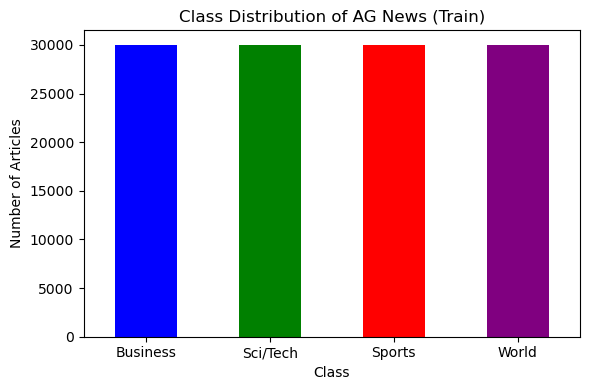

In [29]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['blue','green','red','purple'])
ax.set_title('Class Distribution of AG News (Train)')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
train_df['Title'].str.split()

0                                     [Wall, St., Bears, Claw, Back, Into, the, Black, (Reuters)]
1                                      [Carlyle, Looks, Toward, Commercial, Aerospace, (Reuters)]
2                                         [Oil, and, Economy, Cloud, Stocks', Outlook, (Reuters)]
3                          [Iraq, Halts, Oil, Exports, from, Main, Southern, Pipeline, (Reuters)]
4         [Oil, prices, soar, to, all-time, record,, posing, new, menace, to, US, economy, (AFP)]
                                                   ...                                           
119995                                [Pakistan's, Musharraf, Says, Won't, Quit, as, Army, Chief]
119996                                                    [Renteria, signing, a, top-shelf, deal]
119997                                                     [Saban, not, going, to, Dolphins, yet]
119998                                                                      [Today's, NFL, games]
119999              

In [32]:
train_df['Title'].str.split().apply(len)

0          9
1          6
2          7
3          9
4         13
          ..
119995     8
119996     5
119997     6
119998     3
119999     5
Name: Title, Length: 120000, dtype: int64

In [35]:
train_df['title_len'] = train_df['Title'].str.split().apply(len)
train_df['desc_len'] = train_df['Description'].str.split().apply(len)

In [36]:
train_df

,Class Index,Title,Description,Class Name,title_len,desc_len
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",Business,9,12
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\contr...",Business,6,30
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over...,Business,7,29
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed...,Business,9,27
4,3,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three ...",Business,13,24
...,...,...,...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a ple...",World,8,31
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a neces...,Sports,5,50
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy b...,Sports,6,37
119998,2,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steele...",Sports,3,61


In [37]:
print(train_df['title_len'].mean(), train_df['title_len'].min(), train_df['title_len'].max())

6.784108333333333 1 19


In [38]:
print(train_df['desc_len'].mean(), train_df['desc_len'].min(), train_df['desc_len'].max())

31.060508333333335 1 173


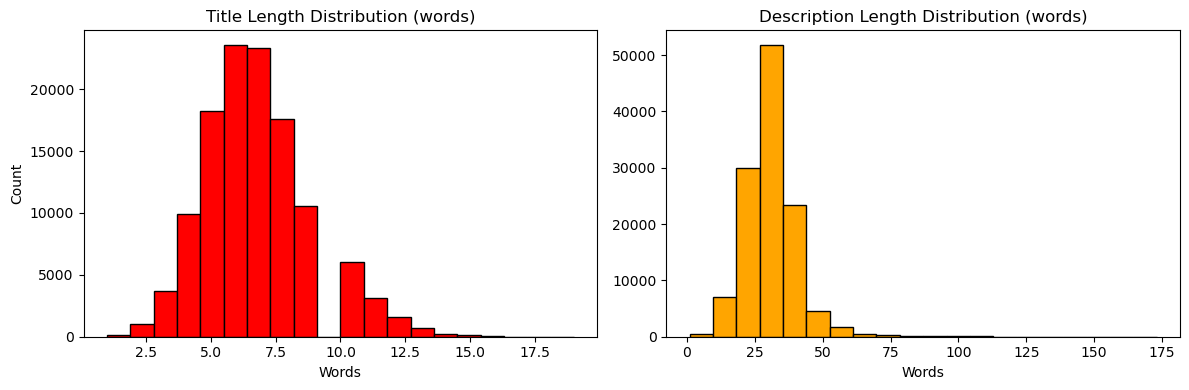

In [39]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].hist(train_df['title_len'], bins=20, color='red', edgecolor='black')
axes[0].set_title('Title Length Distribution (words)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['desc_len'], color='orange', bins=20, edgecolor='black')
axes[1].set_title('Description Length Distribution (words)')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

In [42]:
all_words = " ".join(train_df['Title'] + " " + train_df['Description']).lower().split()
all_words

['wall',
 'st.',
 'bears',
 'claw',
 'back',
 'into',
 'the',
 'black',
 '(reuters)',
 'reuters',
 '-',
 'short-sellers,',
 'wall',
 "street's",
 'dwindling\\band',
 'of',
 'ultra-cynics,',
 'are',
 'seeing',
 'green',
 'again.',
 'carlyle',
 'looks',
 'toward',
 'commercial',
 'aerospace',
 '(reuters)',
 'reuters',
 '-',
 'private',
 'investment',
 'firm',
 'carlyle',
 'group,\\which',
 'has',
 'a',
 'reputation',
 'for',
 'making',
 'well-timed',
 'and',
 'occasionally\\controversial',
 'plays',
 'in',
 'the',
 'defense',
 'industry,',
 'has',
 'quietly',
 'placed\\its',
 'bets',
 'on',
 'another',
 'part',
 'of',
 'the',
 'market.',
 'oil',
 'and',
 'economy',
 'cloud',
 "stocks'",
 'outlook',
 '(reuters)',
 'reuters',
 '-',
 'soaring',
 'crude',
 'prices',
 'plus',
 'worries\\about',
 'the',
 'economy',
 'and',
 'the',
 'outlook',
 'for',
 'earnings',
 'are',
 'expected',
 'to\\hang',
 'over',
 'the',
 'stock',
 'market',
 'next',
 'week',
 'during',
 'the',
 'depth',
 'of',
 'the\

In [43]:
len(all_words)

4541354

In [45]:
vocab_rough = set(all_words)
vocab_rough

{'okur',
 '(r2.7',
 'unjustly',
 'virginia-virginia',
 'endicott',
 'dutchman',
 '"disappointed"',
 'carotid',
 'spaced',
 'joint',
 'ilex',
 'sorrows',
 'lovell',
 "falluja'",
 'bellamy.',
 '38-36',
 'yeast',
 'bean',
 'formats:',
 'chile-ap)',
 'helium',
 'goal!.',
 '285,',
 'hold\\the',
 'search123,',
 "chief's",
 'spiders',
 'hurlbert',
 'wednesday\\after',
 'resort.',
 'sharma,',
 'kernel-level',
 'petrino',
 'fallers',
 'pro-u.s.',
 '#36;536',
 'intellectual',
 'display.',
 '(517',
 'battlefields',
 'weather,',
 'beep!',
 'weekly.',
 'kinshasa',
 'randomly',
 'sunblock:',
 '"crane.',
 'over\\dallas',
 'kanoodle,',
 'renters',
 '09:02',
 'technology-focused',
 'salt.',
 'talke',
 'ipaq',
 'bookmakers.',
 'persisting',
 'baghdad/falluja,',
 '19-16',
 'wobbling',
 'draft?',
 'minneapolis,',
 'george',
 'href="http://www.investor.reuters.com/fullquote.aspx?ticker=amtd.o',
 't-vs.',
 'torretta',
 'sugiyama,',
 'presidenciales',
 'marching',
 'network:',
 '9,803.74',
 'shlomo',
 'senti

In [46]:
len(vocab_rough)

158715

In [47]:
combined_len = train_df['title_len'] + train_df['desc_len']
longest_idx = combined_len.idxmax()
shortest_idx = combined_len.idxmin()

In [48]:
print(train_df.loc[longest_idx,'Title'])

2004 US Senate Outlook


In [49]:
print(train_df.loc[longest_idx,'Description'])

With all the hoopla over Bush and Kerry, some of you may not have been paying close attention to the other races going on in this loaded US political season. I've read a good dozen or so Senate outlooks, and my blurry eyes and spinning brain kept getting lost in all the numbers and losing track of who, ultimately, was likely to control the Senate on November third. So I made my very own Senate outlook to figure it out (or add further confusion, depending on what you think of my predictions). The bad news is, we probably won't know who controls the Senate on November third. The good news, if you're a Democrat (or a person who loves one), is that my best guess at this point is that when the dust settles, Democrats will probably be in control by the very slimmest possible margin. Shock! But everyone knows the Dems have no chance of taking either house of Congress. I think everyone hasn't been paying attention. Read on for my rundown.


In [50]:
print(train_df.loc[shortest_idx,'Title'])

Top of 3rd


In [51]:
print(train_df.loc[shortest_idx,'Description'])

#NAME?


In [52]:
import re

def to_lowercase(text: str) -> str:
    return text.lower()

def remove_punctuation(text: str) -> str:
    return re.sub(r"[^\w\s]", " ", text)

def remove_numbers(text: str) -> str:
    return re.sub(r"\d+", " ", text)

def remove_extra_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text: str) -> str:
    text = to_lowercase(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_extra_spaces(text)
    return text

sample = "Yesterday, Intel took the wraps off of a speedier version of its Pentium M, the heart of the company #39;s wireless..."
print('Before:', sample)
print('After:', clean_text(sample))

Before: Yesterday, Intel took the wraps off of a speedier version of its Pentium M, the heart of the company #39;s wireless...
After: yesterday intel took the wraps off of a speedier version of its pentium m the heart of the company s wireless


In [53]:
train_df['Description'].sample()

44225    Several speakers at this week's EPCglobal conference talked about how RFID tagging can help companies track products...
Name: Description, dtype: object

In [54]:
train_df

,Class Index,Title,Description,Class Name,title_len,desc_len
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",Business,9,12
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\contr...",Business,6,30
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over...,Business,7,29
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed...,Business,9,27
4,3,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three ...",Business,13,24
...,...,...,...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a ple...",World,8,31
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a neces...,Sports,5,50
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy b...,Sports,6,37
119998,2,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steele...",Sports,3,61


In [55]:
train_df['text'] = (train_df['Title'] + " " + train_df['Description']).apply(clean_text)
test_df['text'] = (test_df['Title'] + " " + test_df['Description']).apply(clean_text)

In [56]:
train_df[['Title', 'Description', 'text']]

,Title,Description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics ar...
1,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\contr...",carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle group which has a reputati...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over...,oil and economy cloud stocks outlook reuters reuters soaring crude prices plus worries about the economy and the out...
3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed...,iraq halts oil exports from main southern pipeline reuters reuters authorities have halted oil export flows from the...
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three ...",oil prices soar to all time record posing new menace to us economy afp afp tearaway world oil prices toppling record...
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a ple...",pakistan s musharraf says won t quit as army chief karachi reuters pakistani president pervez musharraf has said he ...
119996,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a neces...,renteria signing a top shelf deal red sox general manager theo epstein acknowledged edgar renteria was more a luxury...
119997,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy b...,saban not going to dolphins yet the miami dolphins will put their courtship of lsu coach nick saban on hold to compl...
119998,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steele...",today s nfl games pittsburgh at ny giants time p m line steelers by records steelers giants vs spread steelers giant...


In [57]:
def tokenize(text: str) -> list:
    return text.split()

train_df['tokens'] = train_df['text'].apply(tokenize)
test_df['tokens'] = test_df['text'].apply(tokenize)

print('Example text:', train_df['text'].iloc[0])
print('Example tokens:', train_df['tokens'].iloc[0])

Example text: wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are seeing green again
Example tokens: ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']


In [60]:
train_df.sample()

,Class Index,Title,Description,Class Name,title_len,desc_len,text,tokens
80549,2,Pistons are grand in opener,"After getting their championship rings and sending the banner up into the rafters, the Pistons started their title d...",Sports,5,27,pistons are grand in opener after getting their championship rings and sending the banner up into the rafters the pi...,"[pistons, are, grand, in, opener, after, getting, their, championship, rings, and, sending, the, banner, up, into, t..."


In [61]:
from collections import Counter

MIN_FREQ = 2

word_counter = Counter()

for tokens in train_df['tokens']:
    word_counter.update(tokens)
print('Total unique words before frequency filtering:', len(word_counter))

kept_words = [word for word, freq in word_counter.items() if freq >= MIN_FREQ]
print('Unique words after filtering', len(kept_words))

Total unique words before frequency filtering: 61840
Unique words after filtering 42305


In [62]:
kept_words

['wall',
 'st',
 'bears',
 'claw',
 'back',
 'into',
 'the',
 'black',
 'reuters',
 'short',
 'sellers',
 'street',
 's',
 'dwindling',
 'band',
 'of',
 'ultra',
 'cynics',
 'are',
 'seeing',
 'green',
 'again',
 'carlyle',
 'looks',
 'toward',
 'commercial',
 'aerospace',
 'private',
 'investment',
 'firm',
 'group',
 'which',
 'has',
 'a',
 'reputation',
 'for',
 'making',
 'well',
 'timed',
 'and',
 'occasionally',
 'controversial',
 'plays',
 'in',
 'defense',
 'industry',
 'quietly',
 'placed',
 'its',
 'bets',
 'on',
 'another',
 'part',
 'market',
 'oil',
 'economy',
 'cloud',
 'stocks',
 'outlook',
 'soaring',
 'crude',
 'prices',
 'plus',
 'worries',
 'about',
 'earnings',
 'expected',
 'to',
 'hang',
 'over',
 'stock',
 'next',
 'week',
 'during',
 'depth',
 'summer',
 'doldrums',
 'iraq',
 'halts',
 'exports',
 'from',
 'main',
 'southern',
 'pipeline',
 'authorities',
 'have',
 'halted',
 'export',
 'flows',
 'after',
 'intelligence',
 'showed',
 'rebel',
 'militia',
 'coul

In [63]:
sorted(kept_words)

['_',
 'a',
 'aa',
 'aaa',
 'aac',
 'aachen',
 'aai',
 'aaliyah',
 'aapl',
 'aapt',
 'aarde',
 'aaron',
 'aathar',
 'ab',
 'ababa',
 'abacha',
 'abaco',
 'abagnale',
 'abandon',
 'abandoned',
 'abandoning',
 'abandonment',
 'abandons',
 'abare',
 'abate',
 'abated',
 'abating',
 'abaya',
 'abb',
 'abbas',
 'abbey',
 'abbn',
 'abbott',
 'abboud',
 'abbreviated',
 'abby',
 'abc',
 'abcs',
 'abd',
 'abdallah',
 'abdel',
 'abdicate',
 'abdicated',
 'abdicates',
 'abdicating',
 'abdication',
 'abdomen',
 'abdoulaye',
 'abduct',
 'abducted',
 'abductee',
 'abductees',
 'abducting',
 'abduction',
 'abductions',
 'abductors',
 'abdul',
 'abdullah',
 'abdullahi',
 'abdur',
 'abe',
 'abella',
 'aber',
 'abercrombie',
 'aberdeen',
 'aberhet',
 'aberration',
 'abetting',
 'abg',
 'abhorrent',
 'abide',
 'abidine',
 'abiding',
 'abidjan',
 'abigail',
 'abilities',
 'ability',
 'abimael',
 'abiomed',
 'abject',
 'abkhazia',
 'abl',
 'ablaze',
 'able',
 'ably',
 'abn',
 'abnormal',
 'aboard',
 'abode

In [65]:
PAD_TOKEN, UNK_TOKEN = '<PAD>','<UNK>'
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for word in sorted(kept_words):
    word2idx[word] = len(word2idx)

idx2word = {idx : word for word, idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)

print('Final vocabulary size(including <PAD> and <UNK>):', VOCAB_SIZE)
print('Example mappings:')

for w in ['<PAD>','<UNK>', 'stocks','capital','nepal','kathmandu']:
    if w in word2idx:
        print(f"{w} -> {word2idx[w]}")

Final vocabulary size(including <PAD> and <UNK>): 42307
Example mappings:
<PAD> -> 0
<UNK> -> 1
stocks -> 36008
capital -> 5609
nepal -> 25171
kathmandu -> 20150
